# 18 — Proposal figure: single panel, real image

Single-panel proposal figure using the real `fuji6_asi178_100_15s.fit` image.

**Design:**
- Sigma-based lower clip cuts noise pinpricks; only stars and spectral traces are visible
- WCS coordinate grid + catalog-matched star circles
- North/East compass fiducial
- Grating angle arrow (placeholder now — replace Cell 7 when extraction is implemented)

**Run from the `Python (spectrangle WSL)` kernel.**


## 1 · Imports


In [1]:
import sys, shutil, warnings, time, platform, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.wcs.utils import proj_plane_pixel_scales

_pkg = str(Path('..').resolve())
if _pkg not in sys.path:
    sys.path.insert(0, _pkg)

from extractor import extract_stars
from extractor.platesolve import solve_plate, LocalSolveFieldError
from extractor.wcsangle import (
    center_wcs_angle_metrics, angle_diff_deg, local_north_angle_deg
)

BACKEND_CFG = '/mnt/c/Users/bassd/.astrometry/backend.cfg'
INDEX_DIR   = Path('/mnt/c/Users/bassd/astrometry-data/4100/')

def _make_wcs(header):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FITSFixedWarning)
        warnings.filterwarnings('ignore', message='.*datfix.*')
        return WCS(header)

import extractor
print(f'extractor   : {extractor.__version__}')
print(f'Platform    : {platform.system()} {platform.release()}')
if platform.system() == 'Windows':
    print('*** Switch to the Python (spectrangle WSL) kernel.')
print(f'solve-field : {shutil.which("solve-field") or "NOT FOUND"}')


extractor   : 0.2.0
Platform    : Linux 5.15.167.4-microsoft-standard-WSL2
solve-field : /usr/bin/solve-field


## 2 · Parameters

### Stretch knobs

| Parameter | Effect |
|:----------|:-------|
| `SIGMA_THRESH` | Lower clip in sky-noise units. **Raise** to cut more noise pinpricks. **Lower** to show fainter stars. Try 2–8. |
| `VHIGH_PCT` | Upper percentile of above-threshold pixels. Lower to prevent bright-star saturation. |
| `STRETCH_GAMMA` | Power-law exponent after clipping. `1.0` = linear (cleanest when noise is cut). `0.5` = sqrt (more midtones). |


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
IMAGE_FILE = Path('..') / 'data' / 'fig' / 'fuji6_asi178_100_15s.fit'
OUT_DIR    = Path('..') / 'out' / 'proposal_fig_real'
OUT_DIR.mkdir(parents=True, exist_ok=True)

NB10_FID  = Path('..') / 'out' / 'local_bootstrap_10' / 'fiducial_result.pkl'
NB10_SRC  = Path('..') / 'out' / 'local_bootstrap_10' / 'sources.pkl'
SRC_CACHE = OUT_DIR / 'sources.pkl'
FID_CACHE = OUT_DIR / 'fiducial.pkl'

# ── Stretch ───────────────────────────────────────────────────────────────────
BG_SIGMA     = 50.0   # Gaussian background kernel (px)
SIGMA_THRESH = 3.0    # lower clip in sky-rms units; raise to cut more noise
VHIGH_PCT    = 99.5   # upper clip: percentile of pixels ABOVE the sigma threshold
STRETCH_GAMMA = 1.0   # 1.0=linear, 0.5=sqrt — linear is cleanest after sigma cut

# ── Figure ────────────────────────────────────────────────────────────────────
CMAP          = 'gray'      # white stars on black sky — do not change to gray_r
FIG_W         = 10.0        # figure width  (inches)
FIG_H         = 7.0         # figure height (inches)
FIG_DPI       = 150
FIG_OUT       = OUT_DIR / 'proposal_real.png'

# Overlay colours (drawn on dark image — keep bright for visibility)
DET_COLOR     = '#44ff88'   # detected sources
MATCH_COLOR   = '#ff9900'   # catalog-matched sources
COMPASS_COLOR = '#ffe066'   # N/E arrows
GRATING_COLOR = '#ff6b6b'   # grating angle arrow
GRID_COLOR    = '#4477aa'   # WCS coordinate grid

DET_SZ        = 14          # detected marker area (pt²)
MATCH_SZ      = 70          # matched marker area  (pt²)
MATCH_LW      = 1.3

# Compass position and size
COMPASS_X_FRAC  = 0.10      # base x as fraction of image width
COMPASS_Y_FRAC  = 0.12      # base y as fraction of image height
COMPASS_LEN_FRAC = 0.07     # arrow length as fraction of min(nx, ny)
COMPASS_FS      = 13

# Annotation box inside the image (set SHOW_ANN=False to omit entirely)
SHOW_ANN      = True

# Solve parameters (real image)
SCALE_LOW     = 70.0
SCALE_HIGH    = 95.0
TWEAK_ORDER   = 5

print(f'Image  : {IMAGE_FILE}  exists={IMAGE_FILE.exists()}')
print(f'nb10   : fid={NB10_FID.exists()}  src={NB10_SRC.exists()}')
print(f'Output : {OUT_DIR.resolve()}')


Image  : ../data/fig/fuji6_asi178_100_15s.fit  exists=True
nb10   : fid=True  src=True
Output : /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/out/proposal_fig_real


## 3 · Load image and compute stretch

The stretch works in three steps:
1. Subtract large-scale background (Gaussian)
2. Estimate sky noise from the **negative** half of the BG-subtracted image (pure noise, no stars)
3. Zero everything below `SIGMA_THRESH × sky_rms` → noise pinpricks become pure black
4. Apply power-law gamma to the remaining bright range

Adjust `SIGMA_THRESH` in the Parameters cell until the image looks right in the preview below.


Image         : 3096×2080 px
sky_rms       : 0.0105  (from negative-pixel RMS)
Lower clip    : 0.0314  (3.0σ)
Upper clip    : 0.6844  (p99.5 of above-threshold pixels)
Dynamic range : 65σ
Fraction shown: 0.0106


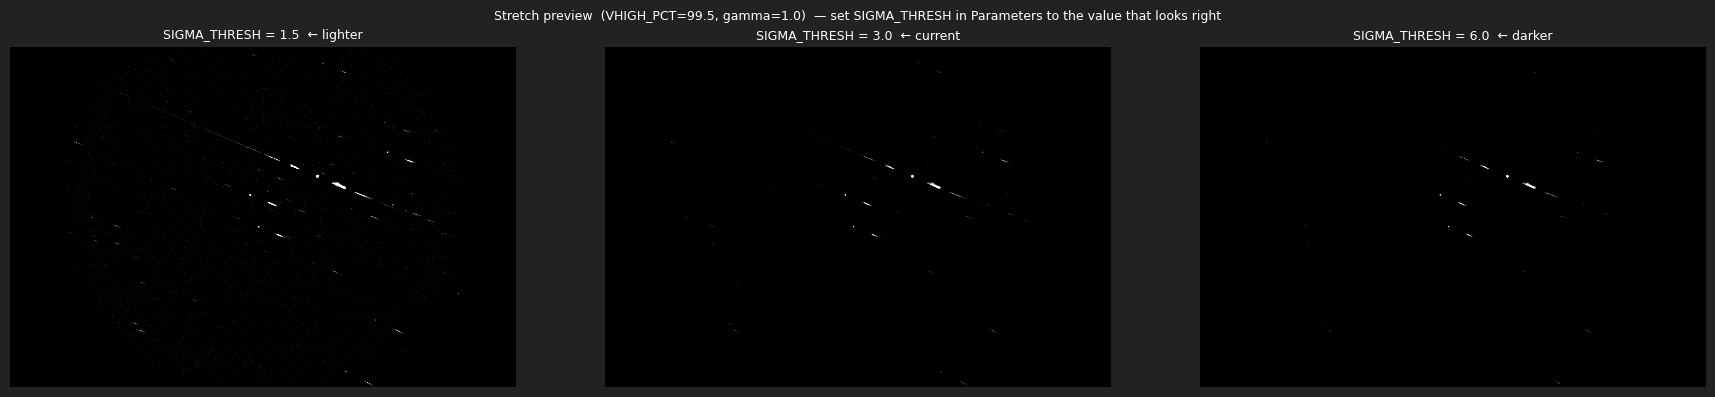

In [3]:
with fits.open(IMAGE_FILE) as h:
    image  = h[0].data.astype(np.float64)
    hdr_orig = h[0].header.copy()

ny, nx = image.shape

# ── Background subtraction ────────────────────────────────────────────────────
bg  = gaussian_filter(image, sigma=BG_SIGMA)
raw = image - bg               # still contains negative noise values

# ── Sky noise estimate from the negative half (pure noise, no signal) ─────────
neg = raw[raw < 0]
sky_rms = float(np.sqrt(np.mean(neg**2)))   # RMS of negative pixels → noise estimate

lo = SIGMA_THRESH * sky_rms

# ── Upper clip ─────────────────────────────────────────────────────────────────
above = raw[raw > lo]
hi = float(np.percentile(above, VHIGH_PCT)) if len(above) else lo + 1.0

# ── Stretch ───────────────────────────────────────────────────────────────────
span = hi - lo
clipped = np.clip((raw - lo) / span, 0.0, 1.0).astype(np.float32)
disp = clipped ** STRETCH_GAMMA if STRETCH_GAMMA != 1.0 else clipped
VMIN, VMAX = 0.0, 1.0

print(f'Image         : {nx}×{ny} px')
print(f'sky_rms       : {sky_rms:.4f}  (from negative-pixel RMS)')
print(f'Lower clip    : {lo:.4f}  ({SIGMA_THRESH}σ)')
print(f'Upper clip    : {hi:.4f}  (p{VHIGH_PCT} of above-threshold pixels)')
print(f'Dynamic range : {hi/sky_rms:.0f}σ')
print(f'Fraction shown: {(raw > lo).mean():.4f}')

# ── Stretch preview ───────────────────────────────────────────────────────────
# Check the look before running the solve.  Re-run Cells 2+3 to iterate quickly.
fig_prev, axes = plt.subplots(1, 3, figsize=(18, 4),
                               facecolor='#222')
sigmas = [SIGMA_THRESH * 0.5, SIGMA_THRESH, SIGMA_THRESH * 2.0]
for ax, sig in zip(axes, sigmas):
    _lo = sig * sky_rms
    _hi = float(np.percentile(raw[raw > _lo], VHIGH_PCT)) if np.any(raw > _lo) else _lo + 1
    _d  = np.clip((raw - _lo) / (_hi - _lo), 0, 1).astype(np.float32)
    if STRETCH_GAMMA != 1.0:
        _d = _d ** STRETCH_GAMMA
    ax.imshow(_d, origin='lower', cmap=CMAP, vmin=0, vmax=1,
              aspect='equal', interpolation='nearest')
    tag = '← lighter' if sig < SIGMA_THRESH else ('← current' if sig == SIGMA_THRESH else '← darker')
    ax.set_title(f'SIGMA_THRESH = {sig:.1f}  {tag}',
                 fontsize=9, color='white')
    ax.axis('off')
fig_prev.suptitle(
    f'Stretch preview  (VHIGH_PCT={VHIGH_PCT}, gamma={STRETCH_GAMMA})  '
    f'— set SIGMA_THRESH in Parameters to the value that looks right',
    fontsize=9, color='white')
fig_prev.tight_layout()
plt.show()


## 4 · Source detection and plate solve


In [4]:
# ── Source detection ──────────────────────────────────────────────────────────
for p, lbl in [(NB10_SRC, 'nb10'), (SRC_CACHE, 'local')]:
    if p.exists():
        with open(p, 'rb') as f:
            xs, ys, _ = pickle.load(f)
        print(f'Sources: {len(xs)} ({lbl} cache)')
        break
else:
    print('Detecting sources...')
    xs, ys, fl = extract_stars(image.astype(np.float32),
                               max_sources=300, mask_spectra=True)
    with open(SRC_CACHE, 'wb') as f:
        pickle.dump((xs, ys, fl), f)
    print(f'Sources: {len(xs)} (cached)')

# ── Plate solve ───────────────────────────────────────────────────────────────
for p, lbl in [(NB10_FID, 'nb10'), (FID_CACHE, 'local')]:
    if p.exists():
        with open(p, 'rb') as f:
            result = pickle.load(f)
        print(f'Solve  : loaded from {lbl} cache')
        break
else:
    print(f'Running solve ({len(xs)} sources, order {TWEAK_ORDER})...')
    _idx = str(INDEX_DIR / 'index-4117.fits')
    _t0 = time.time()
    try:
        result = solve_plate(
            xs=xs, ys=ys, image_width=nx, image_height=ny,
            original_header=hdr_orig,
            backend='local', backend_config=BACKEND_CFG,
            scale_units='arcsecperpix',
            scale_low=SCALE_LOW, scale_high=SCALE_HIGH,
            tweak_order=TWEAK_ORDER,
            output_dir=OUT_DIR / 'solve',
            timeout=120, verbose=True,
            extra_args=['--index', _idx] if Path(_idx).exists() else None,
        )
    except LocalSolveFieldError as e:
        print(f'Solve failed: {e}')
        result = None
    print(f'Finished in {time.time()-_t0:.1f}s')
    if result is not None:
        with open(FID_CACHE, 'wb') as f:
            pickle.dump(result, f)

if result is None:
    raise RuntimeError('Solve failed — cannot continue.')

wcs     = _make_wcs(result.header)
metrics = center_wcs_angle_metrics(wcs, image.shape, compute_east=True)
_ps     = float(np.mean(np.abs(proj_plane_pixel_scales(wcs))) * 3600)
n_match = (len(result.corr_table) if result.corr_table is not None
           else len(result.matched_x))

print(f'\nWCS summary:')
print(f'  matched   : {n_match}')
print(f'  scale     : {_ps:.2f} arcsec/px')
print(f'  θ_N       : {metrics.north_angle_deg:.4f}°  (CCW from +x pixel axis)')
print(f'  θ_E       : {metrics.east_angle_deg:.4f}°')
print(f'  center    : RA={metrics.ra_deg:.4f}°  Dec={metrics.dec_deg:.4f}°')


Sources: 255 (nb10 cache)
Solve  : loaded from nb10 cache

WCS summary:
  matched   : 86
  scale     : 80.39 arcsec/px
  θ_N       : -107.0058°  (CCW from +x pixel axis)
  θ_E       : 163.0386°
  center    : RA=113.4236°  Dec=30.4264°


## 5 · Figure helpers


In [5]:
def sky_pa_to_pixel_angle(pa_sky_deg, north_angle_deg, east_angle_deg):
    """
    Convert a sky position angle (degrees east of north) to the corresponding
    pixel-space angle (degrees CCW from +x image axis).

    Uses the local north and east pixel directions as an orthogonal basis.
    Valid to ~0.05° for this image (north/east are 179.96° apart, i.e. nearly
    perpendicular in the flipped-parity sense).

    Parameters
    ----------
    pa_sky_deg      : float  — sky PA, degrees east of north
    north_angle_deg : float  — pixel-space direction of north (from center_wcs_angle_metrics)
    east_angle_deg  : float  — pixel-space direction of east

    Returns
    -------
    float — pixel angle, degrees CCW from +x axis
    """
    n = np.array([np.cos(np.radians(north_angle_deg)),
                  np.sin(np.radians(north_angle_deg))])
    e = np.array([np.cos(np.radians(east_angle_deg)),
                  np.sin(np.radians(east_angle_deg))])
    # Sky direction at PA degrees east of north: combine basis vectors
    pa_rad  = np.radians(pa_sky_deg)
    pix_vec = np.cos(pa_rad) * n + np.sin(pa_rad) * e
    return float(np.degrees(np.arctan2(pix_vec[1], pix_vec[0])))


def draw_compass(ax, x_px, y_px, length_px,
                 north_angle_deg, east_angle_deg,
                 color=COMPASS_COLOR, fontsize=COMPASS_FS):
    """Draw N and E compass arrows at pixel position (x_px, y_px)."""
    pix = ax.get_transform('pixel')

    def _arrow(angle_deg, L, lw, ms):
        th = np.radians(angle_deg)
        dx, dy = L * np.cos(th), L * np.sin(th)
        ax.annotate('',
            xy=(x_px + dx, y_px + dy), xytext=(x_px, y_px),
            xycoords=pix, textcoords=pix,
            arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                            mutation_scale=ms))
        return dx, dy

    dx_n, dy_n = _arrow(north_angle_deg, length_px,      lw=2.2, ms=16)
    dx_e, dy_e = _arrow(east_angle_deg,  length_px*0.65, lw=1.6, ms=12)

    ax.text(x_px + 1.30*dx_n, y_px + 1.30*dy_n, 'N',
            transform=pix, color=color, fontsize=fontsize,
            fontweight='bold', ha='center', va='center')
    ax.text(x_px + 1.38*dx_e, y_px + 1.38*dy_e, 'E',
            transform=pix, color=color, fontsize=fontsize*0.80,
            fontweight='bold', ha='center', va='center')


def draw_grating_arrow(ax, x_px, y_px, length_px, pix_angle_deg,
                       pa_sky_deg,
                       color=GRATING_COLOR, lw=2.0, fontsize=11):
    """
    Draw a double-headed grating-angle line through (x_px, y_px).

    Parameters
    ----------
    pix_angle_deg : float — direction in pixel space (CCW from +x)
    pa_sky_deg    : float — sky PA east of north, used for the label
    """
    pix  = ax.get_transform('pixel')
    th   = np.radians(pix_angle_deg)
    half = length_px / 2.0
    ax.plot(
        [x_px - half*np.cos(th), x_px + half*np.cos(th)],
        [y_px - half*np.sin(th), y_px + half*np.sin(th)],
        color=color, linewidth=lw, linestyle='-',
        transform=pix, solid_capstyle='round')
    # Small tick marks at the ends to distinguish from a ruler
    for sign in (+1, -1):
        tip_x = x_px + sign * half * np.cos(th)
        tip_y = y_px + sign * half * np.sin(th)
        perp  = th + np.pi/2
        tick  = length_px * 0.06
        ax.plot(
            [tip_x - tick*np.cos(perp), tip_x + tick*np.cos(perp)],
            [tip_y - tick*np.sin(perp), tip_y + tick*np.sin(perp)],
            color=color, linewidth=lw*0.8, transform=pix)
    # Label at the positive tip
    label = f'grating  PA = {pa_sky_deg:.1f}°'
    ax.text(x_px + (half + length_px*0.08)*np.cos(th),
            y_px + (half + length_px*0.08)*np.sin(th),
            label, transform=pix, color=color,
            fontsize=fontsize, fontstyle='italic',
            ha='left' if np.cos(th) >= 0 else 'right', va='center')


print('Helpers defined.')


Helpers defined.


## 6 · Grating / spectra angle

**This is the cell to edit when extraction is implemented.**

Currently `GRATING_PA_SKY` is `None` — no grating arrow is drawn.  
Set it to a float (sky PA east of north, degrees) to preview the fiducial.

When `extractor.detection` / `extractor.fitting` / `extractor.wcsangle` are ready,  
replace the placeholder block with the pipeline call shown in the comment.


In [6]:
# =============================================================================
#  GRATING ANGLE — edit this block in future iterations
# =============================================================================

# ── Placeholder ───────────────────────────────────────────────────────────────
# Set to a float to draw a preview arrow, or leave as None to omit.
GRATING_PA_SKY          = None   # sky PA east of north (degrees)
GRATING_PA_UNCERTAINTY  = None   # 1-sigma uncertainty (degrees); None = omit

# Example — uncomment to test the drawing code before extraction is ready:
# GRATING_PA_SKY = 45.0

# ── Future pipeline call (not yet implemented) ────────────────────────────────
# from extractor.detection import detect_traces     # (Milestone 2)
# from extractor.fitting   import fit_traces        # (Milestone 2)
# from extractor.combine   import combine_angles    # (Milestone 4)
# from extractor.wcsangle  import pixel_angle_to_sky_angle
#
# traces       = detect_traces(image, wcs)
# measurements = fit_traces(traces, image)
# sky_angles   = [
#     pixel_angle_to_sky_angle(wcs, m.x_center, m.y_center, m.theta_pix)
#     for m in measurements
# ]
# combined = combine_angles(sky_angles, weights=[m.weight for m in measurements])
# GRATING_PA_SKY         = combined.theta_sky_deg
# GRATING_PA_UNCERTAINTY = combined.theta_sky_uncertainty_deg
# =============================================================================

# Convert sky PA to pixel angle for drawing (only needed if GRATING_PA_SKY is set)
if GRATING_PA_SKY is not None:
    grating_pix_angle = sky_pa_to_pixel_angle(
        GRATING_PA_SKY,
        metrics.north_angle_deg,
        metrics.east_angle_deg,
    )
    print(f'Grating PA (sky) : {GRATING_PA_SKY:.2f}° E of N')
    print(f'Grating (pixel)  : {grating_pix_angle:.2f}° CCW from +x')
    if GRATING_PA_UNCERTAINTY is not None:
        print(f'Uncertainty      : ±{GRATING_PA_UNCERTAINTY:.2f}°')
else:
    grating_pix_angle = None
    print('GRATING_PA_SKY = None  →  no grating arrow drawn')
    print('Set GRATING_PA_SKY in this cell to preview the fiducial.')


GRATING_PA_SKY = None  →  no grating arrow drawn
Set GRATING_PA_SKY in this cell to preview the fiducial.


## 7 · Proposal figure

Re-run just this cell after tweaking parameters or grating angle — no need to re-solve.


/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages

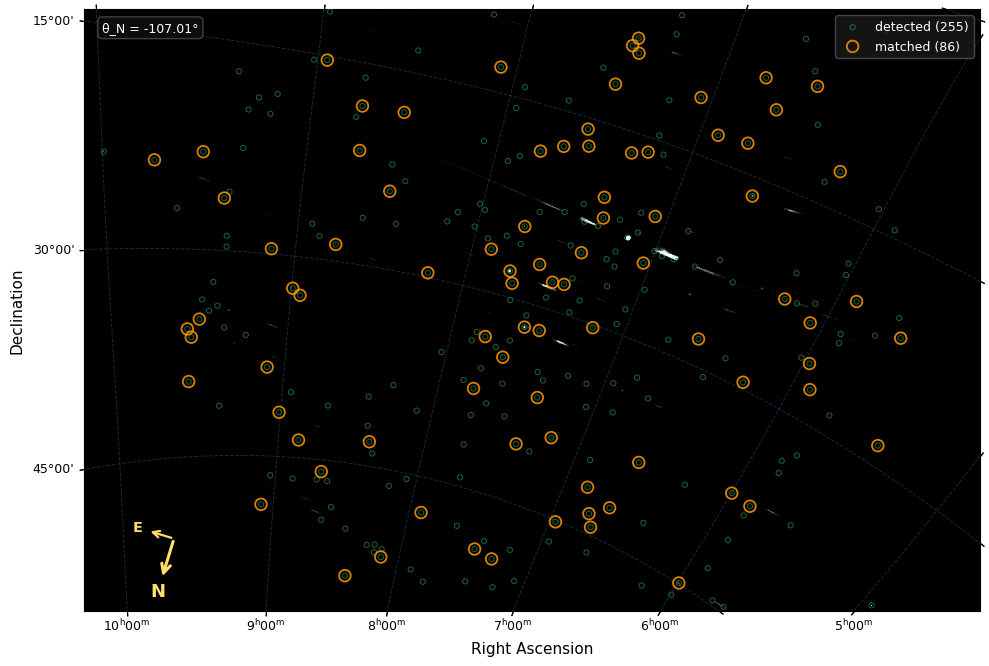

Saved: /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/out/proposal_fig_real/proposal_real.png


In [7]:
plt.rcParams.update({
    'font.family':       'sans-serif',
    'text.color':        'black',
    'axes.labelcolor':   'black',
    'xtick.color':       'black',
    'ytick.color':       'black',
    'axes.edgecolor':    'black',
    'figure.facecolor':  'white',
    'savefig.facecolor': 'white',
    'savefig.dpi':        FIG_DPI,
})

fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor('white')
ax  = fig.add_subplot(1, 1, 1, projection=wcs)
ax.set_facecolor('black')

# ── Image ─────────────────────────────────────────────────────────────────────
ax.imshow(disp, origin='lower', cmap=CMAP,
          vmin=VMIN, vmax=VMAX,
          aspect='equal', interpolation='nearest')

# ── WCS coordinate grid ───────────────────────────────────────────────────────
ax.coords.grid(True, color=GRID_COLOR, alpha=0.35, linestyle='--', linewidth=0.7)
ax.coords['ra'].set_major_formatter('hh:mm')
ax.coords['dec'].set_major_formatter('dd:mm')
ax.coords['ra'].set_axislabel('Right Ascension', fontsize=11, color='black')
ax.coords['dec'].set_axislabel('Declination',    fontsize=11, color='black')
ax.coords['ra'].set_ticklabel(color='black', size=9)
ax.coords['dec'].set_ticklabel(color='black', size=9)
ax.coords['ra'].set_ticks(color='black')
ax.coords['dec'].set_ticks(color='black')

# ── Source overlays ───────────────────────────────────────────────────────────
pix = ax.get_transform('pixel')

ax.scatter(result.detected_x, result.detected_y,
           transform=pix, s=DET_SZ,
           facecolors='none', edgecolors=DET_COLOR,
           linewidths=0.7, alpha=0.40, zorder=3,
           label=f'detected ({len(result.detected_x)})')

if result.corr_table is not None and 'field_x' in result.corr_table.colnames:
    mx = np.asarray(result.corr_table['field_x'], dtype=float)
    my = np.asarray(result.corr_table['field_y'], dtype=float)
elif hasattr(result, 'matched_x') and len(result.matched_x):
    mx, my = result.matched_x, result.matched_y
else:
    mx, my = np.array([]), np.array([])

if len(mx):
    ax.scatter(mx, my, transform=pix,
               s=MATCH_SZ, facecolors='none', edgecolors=MATCH_COLOR,
               linewidths=MATCH_LW, alpha=0.85, zorder=4,
               label=f'matched ({len(mx)})')

# ── Orientation fiducial ──────────────────────────────────────────────────────
arrow_len = min(nx, ny) * COMPASS_LEN_FRAC
cx = nx * COMPASS_X_FRAC
cy = ny * COMPASS_Y_FRAC

draw_compass(ax, cx, cy, arrow_len,
             metrics.north_angle_deg, metrics.east_angle_deg)

if grating_pix_angle is not None:
    # Draw from the same base as the compass so PA is visually relative to N
    draw_grating_arrow(ax, cx, cy, arrow_len * 2.0,
                       grating_pix_angle, GRATING_PA_SKY)

# ── Legend ────────────────────────────────────────────────────────────────────
leg = ax.legend(fontsize=9, loc='upper right',
                facecolor='#1a1a1a', edgecolor='#555555', labelcolor='white')

# ── Annotation box ────────────────────────────────────────────────────────────
if SHOW_ANN:
    ann_parts = [f'θ_N = {metrics.north_angle_deg:.2f}°']
    if GRATING_PA_SKY is not None:
        ann_parts.append(f'grating PA = {GRATING_PA_SKY:.1f}° (E of N)')
        if GRATING_PA_UNCERTAINTY is not None:
            ann_parts.append(f'  ± {GRATING_PA_UNCERTAINTY:.2f}°')
    ax.text(0.02, 0.98, '\n'.join(ann_parts),
            transform=ax.transAxes,
            fontsize=9, color='white', va='top', ha='left',
            bbox=dict(facecolor='#111', alpha=0.75,
                      edgecolor='#555', boxstyle='round,pad=0.35'))

fig.tight_layout()
fig.savefig(FIG_OUT, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_OUT.resolve()}')


## Quick reference

| Goal | What to change |
|:-----|:---------------|
| Cut more noise pinpricks | Raise `SIGMA_THRESH` (Cell 2) |
| Show fainter stars | Lower `SIGMA_THRESH` |
| Brighter/dimmer overall | `VHIGH_PCT` — raise to show more dynamic range |
| Add more contrast | Lower `STRETCH_GAMMA` (e.g. 0.7) |
| Test grating angle arrow | Set `GRATING_PA_SKY = <float>` in Cell 6, re-run Cells 6–7 |
| Add real extraction | Replace placeholder block in Cell 6 |
| Bigger north arrow | Raise `COMPASS_LEN_FRAC` (Cell 2) |
| Hide annotation box | `SHOW_ANN = False` (Cell 2) |
| Change figure size | `FIG_W`, `FIG_H` (Cell 2) |
